## Data Preprocessing Phase

### Importing libraries

In [1]:
import tensorflow as tf
import numpy as np 
import pandas as pd

### Defining standard parameters for MobileNetV2

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = 'dataset/FMD_DATASET'

In [3]:
print("Loading Training Data:")


train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset='training',
    seed=42
)

Loading Training Data:
Found 14691 files belonging to 3 classes.
Using 11753 files for training.


In [4]:
print("\nLoading Validation Data:")

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, # Points to the path where your subfolders are stored
    shuffle=True, # Randomizes the order of the images during loading so the model does not learn based on folder/file ordering.
    batch_size=BATCH_SIZE, 
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=42 # makes randomness predictable
)


Loading Validation Data:
Found 14691 files belonging to 3 classes.
Using 2938 files for validation.


In [5]:
class_names = train_dataset.class_names
print(f"\nSuccessfully mapped {len(class_names)} classes: {class_names}")


Successfully mapped 3 classes: ['incorrect_mask', 'with_mask', 'without_mask']


## Part 2 - Building the MobileNetV2 Architecture

### Importing Libraries

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

### Loading pre-trained MobileNetV2 without its top classification layer 

In [7]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Excluding the default ImageNet 1000-class classifier
    weights='imagenet'  # Use pre-trained ImageNet weights
)

### Freezzing the base model layers

In [8]:
base_model.trainable = False

### Building the full model pipeline

In [9]:
inputs = tf.keras.Input(shape=(224, 224, 3)) # must be exactly 224 pixels wide, 224 pixels tall, with 3 color channels (Red, Green, Blue)

### Applying MobileNetV2-specific preprocessing (scales pixel values to [-1, 1])

In [10]:
x = preprocess_input(inputs) # instantly changes all the picture pixels between -1 and 1

### Passing through pre-trained base model

In [11]:
x = base_model(x, training=False)

### Pooling & Classification Head

In [12]:
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)  # Regularization to prevent overfitting
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

### Compiling the model

In [13]:
# We use sparse_categorical_crossentropy because class labels are integer-encoded
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training the Model


### Defining the numbers of epochs

In [15]:
EPOCHS = 10

### Training the model


In [16]:
print("Starting model training...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)
print("\nTraining complete!")

Starting model training...
Epoch 1/10


/Users/rudra/Desktop/ML/ml_env2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


368/368 ━━━━━━━━━━━━━━━━━━━━ 75s 199ms/step - accuracy: 0.9364 - loss: 0.1824 - val_accuracy: 0.9677 - val_loss: 0.0973
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 95s 260ms/step - accuracy: 0.9702 - loss: 0.0908 - val_accuracy: 0.9728 - val_loss: 0.0799
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 112s 305ms/step - accuracy: 0.9762 - loss: 0.0726 - val_accuracy: 0.9748 - val_loss: 0.0752
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 108s 294ms/step - accuracy: 0.9785 - loss: 0.0677 - val_accuracy: 0.9758 - val_loss: 0.0700
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 113s 307ms/step - accuracy: 0.9797 - loss: 0.0610 - val_accuracy: 0.9769 - val_loss: 0.0693
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 122s 331ms/step - accuracy: 0.9828 - loss: 0.0535 - val_accuracy: 0.9765 - val_loss: 0.0700
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 114s 311ms/step - accuracy: 0.9826 - loss: 0.0515 - val_accuracy: 0.9752 - val_loss: 0.0699
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 117s 317ms/step - accuracy: 0.9830 - loss: 0.0496

## Visualizing and Saving the model 

### Saving the file on the disk

In [17]:
import matplotlib.pyplot as plt

model.save('ppe_mask_model.keras')
print("Model successfully saved as 'ppe_mask_model.keras'")

Model successfully saved as 'ppe_mask_model.keras'


### Extracting the metrics from the training history

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

### Ploting Accuracy

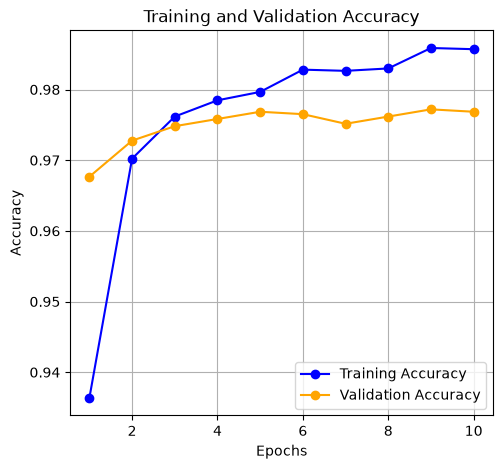

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

### Ploting Loss

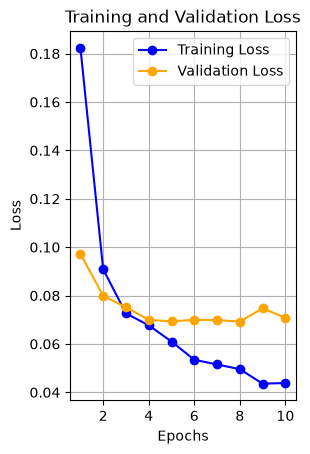

In [20]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

In [21]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>